# Face Anti-Spoofing (Liveness) Detection - Model Training
Notebook ini berisi *pipeline* pelaihan model menggunakan **EfficientNetB0**.
Kita hanya menggunakan data dari folder `output` (wajah yang sudah di-crop) dan menerapkan teknik *resize with pad* agar rasio asli wajah tidak terdistorsi.

In [3]:
# Import Library yang dibutuhkan
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# Pastikan TensorFlow mendeteksi GPU (jika ada)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Using device: cuda
Num GPUs Available:  0


## 1. Persiapan Data (Path & Label)
Mengumpulkan semua *path* gambar dari folder `output` dan melakukan *encoding* pada label kelas (mengubah nama kelas menjadi angka).

In [5]:
# Konfigurasi Path dan Hyperparameter
BASE_DIR = '../FaceBoundingBox'
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

IMG_SIZE = 224 # Ukuran standar untuk EfficientNetB0
BATCH_SIZE = 32

# Mengumpulkan path dan label
image_paths = []
labels = []

classes = [d for d in os.listdir(OUTPUT_DIR) if os.path.isdir(os.path.join(OUTPUT_DIR, d))]
print(f"Kelas yang dideteksi: {classes}")

for cls in classes:
    class_dir = os.path.join(OUTPUT_DIR, cls)
    for img_path in glob.glob(os.path.join(class_dir, '*.*')):
        image_paths.append(img_path)
        labels.append(cls)

# Encode label (String -> Integer)
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)
num_classes = len(classes)

print(f"Total Gambar: {len(image_paths)}")
print(f"Mapping Label: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Kelas yang dideteksi: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']
Total Gambar: 1435
Mapping Label: {np.str_('fake_mannequin'): np.int64(0), np.str_('fake_mask'): np.int64(1), np.str_('fake_printed'): np.int64(2), np.str_('fake_screen'): np.int64(3), np.str_('fake_unknown'): np.int64(4), np.str_('realperson'): np.int64(5)}


## 2. Train-Validation Split & tf.data.Dataset Pipeline
Kita membagi data menjadi 80% *Training* dan 20% *Validation*. Kemudian, kita membangun *pipeline* `tf.data` untuk memuat gambar, melakukan *resize* dengan *padding* (agar tidak gepeng), secara efisien.

In [6]:
# Split Data (80% Train, 20% Val)
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
)

print(f"Data Train: {len(X_train)} | Data Val: {len(X_val)}")

# Fungsi Preprocessing (Membaca gambar & Resize dengan Padding)
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    
    # KUNCI: Resize dengan padding hitam untuk menjaga rasio aspek (menghindari distorsi wajah)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    
    # Ubah tipe data ke float32. 
    # Catatan: EfficientNet Keras mengharapkan piksel 0-255, jadi TIDAK PERLU dibagi 255.0
    img = tf.cast(img, tf.float32)
    
    return img, label

# Membangun Pipeline tf.data untuk Performa Optimal
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(process_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(process_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

Data Train: 1148 | Data Val: 287


## 3. Data Augmentation
Augmentasi diaplikasikan hanya pada tahap *training*. Kita menggunakan augmentasi yang aman (rotasi kecil, flip horizontal, dan zoom kecil) agar tidak merusak tekstur asli *spoofing* seperti pola layar atau tekstur kertas cetak.

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), # Rotasi +- 10% agar tekstur tidak terlalu blur/rusak
    layers.RandomZoom(0.1),
], name="data_augmentation_layer")

## 4. Membangun Arsitektur Model (EfficientNetB0)
Kita menggunakan *Transfer Learning*. Lapisan bawah (base model) dikunci (*frozen*), dan kita menambahkan lapisan klasifikasi baru (*head*) di bagian atas untuk mendeteksi kelas wajah kita.

In [8]:
def build_model(num_classes):
    # Load Pre-trained EfficientNetB0 tanpa top classification layer
    base_model = EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze the base_model agar bobot imagenet tidak rusak di awal training
    base_model.trainable = False
    
    # Membangun top layer
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False) # Pastikan BatchNorm layer jalan di mode inference
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x) # Dropout untuk mencegah overfitting
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 5. Konfigurasi Training & Callbacks
Menambahkan *Early Stopping* untuk berhenti otomatis jika model sudah tidak berkembang, dan *Model Checkpoint* untuk menyimpan bobot model yang terbaik.

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(
        filepath='best_efficientnet_liveness.keras', 
        monitor='val_loss', 
        save_best_only=True
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

## 6. Training Model (Tahap 1 - Feature Extraction)
Melatih hanya lapisan atas (*head*) yang baru saja kita tambahkan.

In [10]:
EPOCHS = 20

print("Memulai Training Tahap 1...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

Memulai Training Tahap 1...
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 57s 851ms/step - accuracy: 0.5192 - loss: 1.3489 - val_accuracy: 0.6028 - val_loss: 1.1225 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 878ms/step - accuracy: 0.6943 - loss: 0.9055 - val_accuracy: 0.6481 - val_loss: 0.9642 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 862ms/step - accuracy: 0.7439 - loss: 0.7639 - val_accuracy: 0.6446 - val_loss: 0.8949 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 807ms/step - accuracy: 0.7500 - loss: 0.7005 - val_accuracy: 0.6934 - val_loss: 0.8338 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 721ms/step - accuracy: 0.7831 - loss: 0.6382 - val_accuracy: 0.7038 - val_loss: 0.7839 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 727ms/step - accuracy: 0.7866 - loss: 0.6146 - val_accuracy: 0.7317 - val_loss: 0.7682 - learning_rate: 0.0010
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 696ms/step -

## 7. Fine Tuning (Tahap 2 - Opsional tapi Direkomendasikan)
Setelah lapisan atas dilatih, kita membuka (*unfreeze*) beberapa lapisan paling atas dari `base_model` EfficientNet untuk menyesuaikan fitur-fiturnya secara spesifik dengan dataset liveness kita. Kita menggunakan *learning rate* yang jauh lebih kecil.

In [11]:
# Unfreeze base model
base_model.trainable = True

# Kita biarkan 100 layer pertama tetap beku, dan melatih sisa layernya
for layer in base_model.layers[:20]:
    layer.trainable = False

# Compile ulang dengan learning rate yang sangat kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai Training Tahap 2 (Fine-Tuning)...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, # Tambahan epoch
    callbacks=callbacks_list
)

Memulai Training Tahap 2 (Fine-Tuning)...
Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.4678 - loss: 1.5159 - val_accuracy: 0.7979 - val_loss: 0.6357 - learning_rate: 1.0000e-06
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.4608 - loss: 1.5372 - val_accuracy: 0.7143 - val_loss: 0.7978 - learning_rate: 1.0000e-06
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.4756 - loss: 1.4855 - val_accuracy: 0.6307 - val_loss: 0.9892 - learning_rate: 1.0000e-06
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.4765 - loss: 1.4771 - val_accuracy: 0.5401 - val_loss: 1.1357 - learning_rate: 1.0000e-06
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.4913 - loss: 1.4177 - val_accuracy: 0.5261 - val_loss: 1.2339 - learning_rate: 1.0000e-06


## 8. Evaluasi Model (Visualisasi Loss & Accuracy)
Melihat grafik performa model selama proses pelatihan.

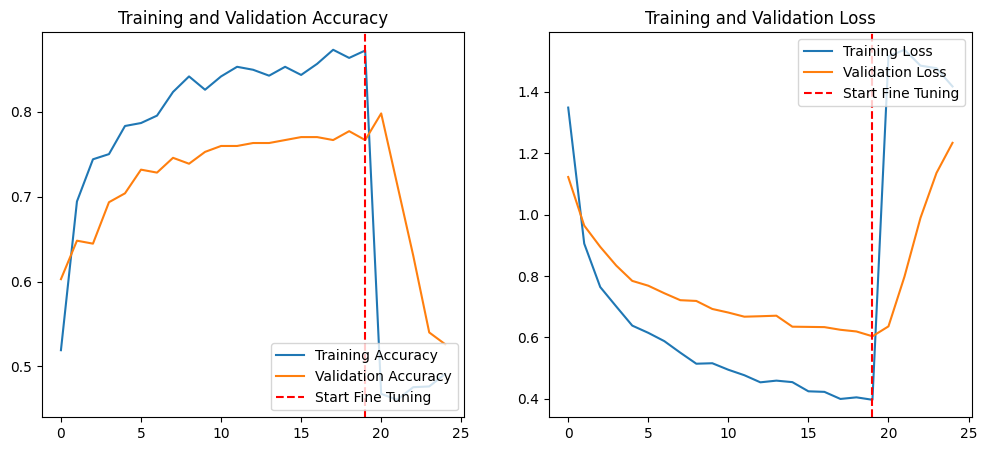

Model dan label berhasil dilatih. File tersimpan: best_efficientnet_liveness.keras & label_classes.npy


In [12]:
# Menggabungkan history dari tahap 1 dan tahap 2
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy'])-1, color='r', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss'])-1, color='r', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Simpan mapping label untuk keperluan inference nanti
np.save('label_classes.npy', le.classes_)
print(f"Model dan label berhasil dilatih. File tersimpan: best_efficientnet_liveness.keras & label_classes.npy")

## 9. Setup 5-Fold Cross Validation
Kita akan menggunakan `StratifiedKFold` dari `scikit-learn`. 
**Aturan Emas K-Fold pada Deep Learning:** Di setiap awal Fold, kita wajib membuat arsitektur model dari nol (*fresh*) agar bobot dari Fold sebelumnya tidak "bocor" (data leakage) ke Fold yang baru.

In [13]:
# Pastikan library ter-import
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Konversi list ke numpy array (pastikan image_paths dan encoded_labels sudah ada dari Cell 4)
X_paths = np.array(image_paths)
y_labels = np.array(encoded_labels)

# Inisialisasi 5-Fold Stratified (Variabel 'skf' dibuat di sini)
EPOCHS_PER_FOLD = 20
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Variabel untuk menyimpan hasil evaluasi tiap fold
fold_accuracies = []
fold_losses = []

print("Variabel skf berhasil didefinisikan. Silakan lanjut jalankan cell berikutnya.")

Variabel skf berhasil didefinisikan. Silakan lanjut jalankan cell berikutnya.


In [14]:
for fold_no, (train_index, val_index) in enumerate(skf.split(X_paths, y_labels), 1):
    print(f"\n{'='*40}")
    print(f"Mengeksekusi FOLD {fold_no}")
    print(f"{'='*40}")
    
    # 1. Alokasi Data untuk Fold ini
    X_train_fold, X_val_fold = X_paths[train_index], X_paths[val_index]
    y_train_fold, y_val_fold = y_labels[train_index], y_labels[val_index]
    
    # 2. Buat Pipeline tf.data.Dataset (Seperti sebelumnya)
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold))
    train_ds = train_ds.map(process_image, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE)
    train_ds = train_ds.prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold))
    val_ds = val_ds.map(process_image, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    
    # 3. KUNCI PENTING: Bersihkan memori GPU dan buat Model Baru (Fresh)
    tf.keras.backend.clear_session() 
    model, base_model = build_model(num_classes)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 4. Setup Callbacks Khusus untuk Fold ini
    # Simpan model terbaik untuk masing-masing fold
    model_filepath = f'best_model_fold_{fold_no}.keras'
    
    callbacks_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        callbacks.ModelCheckpoint(filepath=model_filepath, monitor='val_loss', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
    ]
    
    # 5. Training Tahap 1 (Feature Extraction)
    print("Tahap 1: Melatih Top Layers...")
    model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks_list, verbose=1)
    
    # 6. Training Tahap 2 (Fine Tuning - Opsional tapi disesuaikan)
    # Kita turunkan jumlah layer yang di-unfreeze dan mengecilkan learning rate
    # untuk menghindari grafik yang anjlok seperti yang Anda alami sebelumnya
    print("Tahap 2: Fine-Tuning 20 layer terakhir...")
    base_model.trainable = True
    for layer in base_model.layers[:-20]: # Hanya unfreeze 20 layer teratas
        layer.trainable = False
        
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # Sangat kecil!
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Lanjut training sebentar saja
    model.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=callbacks_list, verbose=1)
    
    # 7. Evaluasi Hasil Akhir Fold
    # Karena ada restore_best_weights=True di atas, model ini adalah versi terbaiknya
    scores = model.evaluate(val_ds, verbose=0)
    print(f"Hasil Akhir Fold {fold_no} -> Loss: {scores[0]:.4f}, Accuracy: {scores[1]:.4f}")
    
    fold_losses.append(scores[0])
    fold_accuracies.append(scores[1])


Mengeksekusi FOLD 1

Tahap 1: Melatih Top Layers...
Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 762ms/step - accuracy: 0.4930 - loss: 1.3913 - val_accuracy: 0.6272 - val_loss: 1.0887 - learning_rate: 0.0010
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 692ms/step - accuracy: 0.7021 - loss: 0.9280 - val_accuracy: 0.6516 - val_loss: 0.8963 - learning_rate: 0.0010
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 686ms/step - accuracy: 0.7361 - loss: 0.7901 - val_accuracy: 0.7143 - val_loss: 0.7960 - learning_rate: 0.0010
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 674ms/step - accuracy: 0.7500 - loss: 0.7285 - val_accuracy: 0.7038 - val_loss: 0.7383 - learning_rate: 0.0010
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 671ms/step - accuracy: 0.7770 - loss: 0.6638 - val_accuracy: 0.7003 - val_loss: 0.7290 - learning_rate: 0.0010
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 697ms/step - accuracy: 0.7918 - loss: 0.6216 - val_accuracy: 0.7526 - val_loss: 0.6844 - learning_rate: 0.0010
Epoch 7/15
36/36 ━━━━━━━━━━━━

## 11. Kesimpulan K-Fold
Menghitung rata-rata performa dari kelima Fold untuk melihat gambaran performa model yang sebenarnya secara keseluruhan.

In [15]:
# Tampilkan rata-rata
print("\n" + "="*40)
print("KESIMPULAN 5-FOLD CROSS VALIDATION")
print("="*40)

for i in range(5):
    print(f"Fold {i+1} - Accuracy: {fold_accuracies[i]*100:.2f}% | Loss: {fold_losses[i]:.4f}")

print("-" * 40)
mean_acc = np.mean(fold_accuracies) * 100
std_acc = np.std(fold_accuracies) * 100
print(f"RATA-RATA AKURASI: {mean_acc:.2f}% (+/- {std_acc:.2f}%)")
print(f"RATA-RATA LOSS   : {np.mean(fold_losses):.4f}")

# Jika ingin menggunakan model untuk deployment/inference,
# Anda bisa me-load model dari Fold yang memiliki akurasi tertinggi:
best_fold = np.argmax(fold_accuracies) + 1
print(f"Model terbaik dihasilkan pada Fold {best_fold} (best_model_fold_{best_fold}.keras)")


KESIMPULAN 5-FOLD CROSS VALIDATION
Fold 1 - Accuracy: 81.18% | Loss: 0.5493
Fold 2 - Accuracy: 82.23% | Loss: 0.5325
Fold 3 - Accuracy: 78.75% | Loss: 0.5943
Fold 4 - Accuracy: 78.40% | Loss: 0.6417
Fold 5 - Accuracy: 78.40% | Loss: 0.6701
----------------------------------------
RATA-RATA AKURASI: 79.79% (+/- 1.60%)
RATA-RATA LOSS   : 0.5976
Model terbaik dihasilkan pada Fold 2 (best_model_fold_2.keras)


# Tahap Inference & Submission
Pada tahap ini, kita akan me-load model terbaik (misalnya dari Fold yang memiliki akurasi tertinggi) dan melakukan prediksi pada data di folder `test`. Hasilnya akan disimpan ke dalam format `submission.csv`.

**PENTING (Harap Diperhatikan):**
Model kita dilatih menggunakan gambar wajah yang **sudah di-crop** (folder `output`). Jika gambar di dalam folder `test` saat ini masih berupa **foto utuh** (seperti folder `train`), idealnya Anda harus melakukan *face detection* (misal menggunakan MTCNN / MediaPipe) dan meng-crop wajahnya terlebih dahulu sebelum dilempar ke model ini. 
Jika folder `test` ternyata sudah berisi wajah yang ter-crop, Anda bisa langsung menjalankan kode ini dengan tenang.

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf

# 1. Konfigurasi Path
TEST_DIR = '../test'
SAMPLE_SUBMISSION_PATH = '../samplesubmission.csv'
OUTPUT_SUBMISSION_PATH = '../submission_ensemble.csv'
IMG_SIZE = 224 

# 2. Load Mapping Kelas
LABEL_CLASSES_PATH = 'label_classes.npy'
print("Loading mapping kelas...")
classes = np.load(LABEL_CLASSES_PATH, allow_pickle=True)
print(f"Daftar Kelas yang dikenali: {classes}")

# 3. Load SEMUA Model (Ensemble)
ensemble_models = []
print("\nMemuat 5 Model untuk Ensemble...")
for i in range(1, 6): # Loop fold 1 sampai 5
    model_path = f'best_model_fold_{i}.keras'
    if os.path.exists(model_path):
        model = tf.keras.models.load_model(model_path)
        ensemble_models.append(model)
        print(f"[OK] {model_path} berhasil dimuat.")
    else:
        print(f"[PERINGATAN] {model_path} tidak ditemukan!")

print(f"\nTotal model dalam Ensemble: {len(ensemble_models)} model.")

Loading mapping kelas...
Daftar Kelas yang dikenali: ['fake_mannequin' 'fake_mask' 'fake_printed' 'fake_screen' 'fake_unknown'
 'realperson']

Memuat 5 Model untuk Ensemble...
[OK] best_model_fold_1.keras berhasil dimuat.
[OK] best_model_fold_2.keras berhasil dimuat.
[OK] best_model_fold_3.keras berhasil dimuat.
[OK] best_model_fold_4.keras berhasil dimuat.
[OK] best_model_fold_5.keras berhasil dimuat.

Total model dalam Ensemble: 5 model.


## Membangun Fungsi Preprocessing Inference
Fungsi ini harus mereplikasi **persis** apa yang terjadi di dalam fungsi `process_image` saat *training* (yaitu membaca gambar, mengubah ke *RGB*, melakukan *resize with pad*, dan mengubah tipe data ke `float32`).

In [23]:
def preprocess_for_inference(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    input_tensor = tf.expand_dims(img, axis=0) 
    return input_tensor

## Looping Prediksi & Pembuatan File Submission
Kita akan membaca isi `samplesubmission.csv`, mengambil ID gambarnya, mencari filenya di folder `test`, melakukan prediksi, dan menyimpan tebakannya kembali ke dataframe.

In [24]:
try:
    df_sub = pd.read_csv(SAMPLE_SUBMISSION_PATH)
except Exception as e:
    print(f"Error membaca {SAMPLE_SUBMISSION_PATH}: {e}")
    df_sub = pd.DataFrame()

predictions = []
print("\nMemulai proses prediksi ENSEMBLE satu per satu...")

if not df_sub.empty and len(ensemble_models) > 0:
    for index, row in df_sub.iterrows():
        img_id = row['id']
        search_pattern = os.path.join(TEST_DIR, f"{img_id}.*")
        found_files = glob.glob(search_pattern)
        
        if len(found_files) == 0:
            predictions.append("unknown")
            continue
            
        img_path = found_files[0]
        
        try:
            input_tensor = preprocess_for_inference(img_path)
            
            # --- PROSES ENSEMBLE MULAI DI SINI ---
            all_model_probs = []
            
            # Minta kelima model menebak
            for model in ensemble_models:
                prob = model.predict(input_tensor, verbose=0)
                all_model_probs.append(prob[0]) # prob[0] karena bentuknya array 2D
                
            # Rata-ratakan hasil probabilitas dari semua model (Soft Voting)
            # Misalnya model 1 yakin 90%, model 2 yakin 80%, dsb.
            avg_probs = np.mean(all_model_probs, axis=0)
            
            # Ambil index probabilitas tertinggi dari nilai rata-rata
            pred_class_idx = np.argmax(avg_probs)
            pred_label = classes[pred_class_idx]
            
            predictions.append(pred_label)
            # ------------------------------------
            
        except Exception as e:
            print(f"[Error] Gagal memproses {img_id}: {e}")
            predictions.append("error")

    # Simpan hasil
    df_sub['label'] = predictions
    df_sub.to_csv(OUTPUT_SUBMISSION_PATH, index=False)
    
    print("\n" + "="*50)
    print("✨ INFERENCE ENSEMBLE SELESAI ✨")
    print(f"File hasil disimpan sebagai: {OUTPUT_SUBMISSION_PATH}")
    print("="*50)
    display(df_sub.head(10))
else:
    print("Prediksi dibatalkan karena data kosong atau model tidak ada.")


Memulai proses prediksi ENSEMBLE satu per satu...

✨ INFERENCE ENSEMBLE SELESAI ✨
File hasil disimpan sebagai: ../submission_ensemble.csv


,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,fake_mask
3,test_004,fake_printed
4,test_005,fake_printed
5,test_006,fake_mannequin
6,test_007,fake_mannequin
7,test_008,fake_unknown
8,test_009,fake_mask
9,test_010,fake_screen
